In [1]:
""" Imports and Path Setup """

%load_ext autoreload
%autoreload 2

import sys
import os

root = os.path.abspath("..")
if root not in sys.path:
    sys.path.insert(0, root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.data_loader import load_raw_data
from src.feature_engineer import get_feature_hypothesis_registry

PROCESSED_PATH = "../data/processed/telecom_customers_processed.csv"
df = pd.read_csv(PROCESSED_PATH)

df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,total_charges,churn,total_charges_outlier_flag,tenure_group,total_addon_services,average_charge_per_month,is_new_customer,has_any_streaming,is_fully_automated_payer,avg_charge_per_month
0,CUST-00005,Male,No,Yes,Yes,53,Yes,No,No,No internet service,...,1553.16,No,0,Loyal (49m+),0,29.304906,0,0,0,29.30
1,CUST-00001,Male,No,No,Yes,61,Yes,No,Fiber optic,Yes,...,5303.45,No,0,Loyal (49m+),1,86.941803,0,0,0,86.94
2,CUST-00002,Female,No,No,No,68,Yes,No,No,No internet service,...,1944.52,No,0,Loyal (49m+),0,28.595882,0,0,0,28.60
3,CUST-00003,Male,No,No,No,62,Yes,No,No,No internet service,...,1736.17,No,0,Loyal (49m+),0,28.002742,0,0,0,28.00
4,CUST-00004,Male,Yes,Yes,No,1,Yes,Yes,DSL,No,...,62.16,Yes,0,New (0-12m),2,62.160000,1,1,0,62.16


In [2]:
hypothesis_registry = get_feature_hypothesis_registry()
hypothesis_registry

,feature,source_columns,business_concept,hypothesis,eda_confirmed
0,tenure_group,tenure_months,Customer lifecycle stage,Churn risk peaks for new customers and decline...,TBD — Class 3
1,total_addon_services,"online_security, online_backup, device_protect...",Service engagement depth,More add-ons = higher switching cost = lower c...,TBD — Class 3
2,avg_charge_per_month,"total_charges, tenure_months, monthly_charges",Effective spend rate,Higher effective spend correlates with price s...,TBD — Class 3
3,is_new_customer,tenure_months,Early churn risk window,First 3 months represent disproportionately hi...,TBD — Class 3
4,has_any_streaming,"streaming_tv, streaming_movies",Entertainment bundle adoption,Streaming users have higher switching cost and...,TBD — Class 3
5,is_fully_automated_payer,payment_method,Payment friction and inertia,Auto-pay customers churn less due to reduced a...,TBD — Class 3


In [3]:
df['churn'].value_counts()

churn
No     3807
Yes    1188
Name: count, dtype: int64

<Axes: xlabel='churn', ylabel='count'>

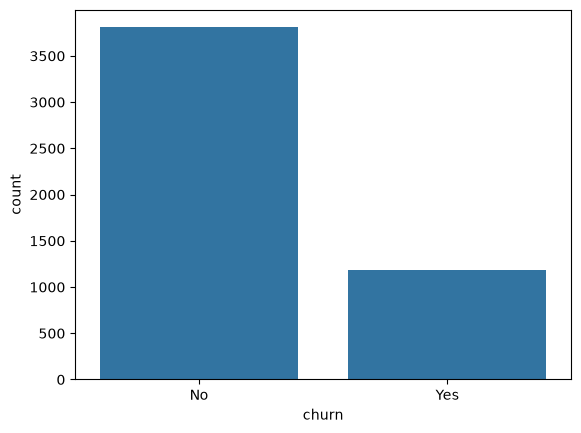

In [4]:
sns.countplot(data=df, x='churn')

<Axes: xlabel='tenure_months', ylabel='Count'>

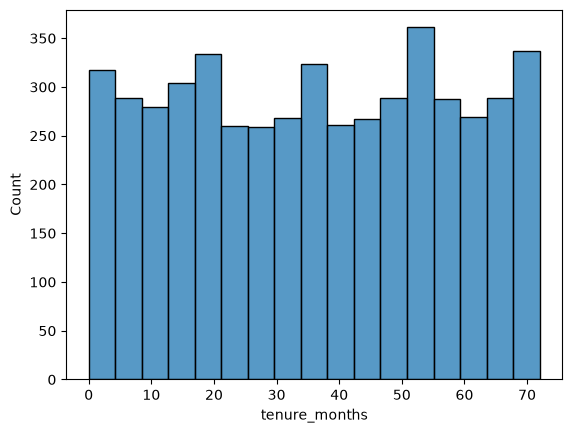

In [5]:
sns.histplot(data=df, x='tenure_months')

<Axes: xlabel='contract_type', ylabel='churn'>

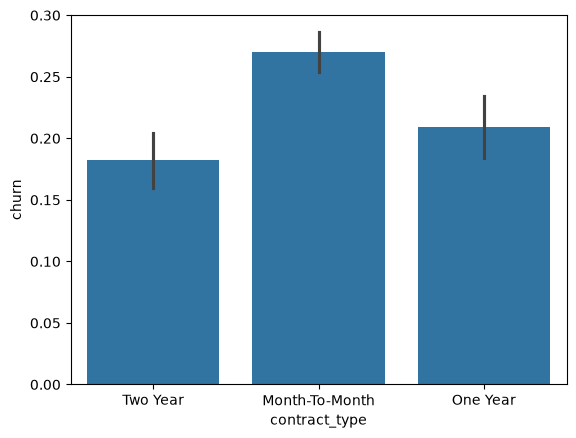

In [6]:
##### EDA : Bivariate Analysis #####
sns.barplot(data=df, x='contract_type', y=df['churn']=="Yes")

<Axes: xlabel='senior_citizen', ylabel='churn'>

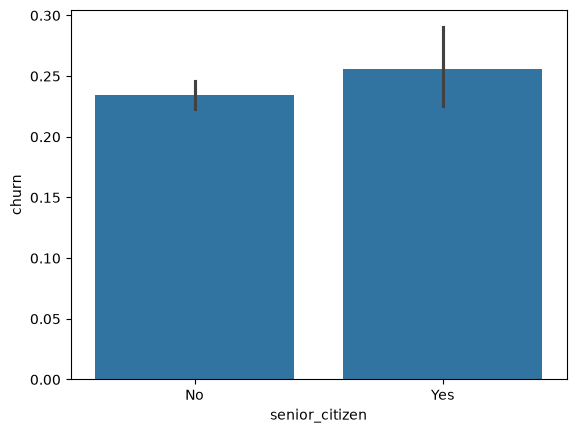

In [7]:
sns.barplot(data=df, x='senior_citizen', y=df['churn']=="Yes")

<Axes: xlabel='partner', ylabel='churn'>

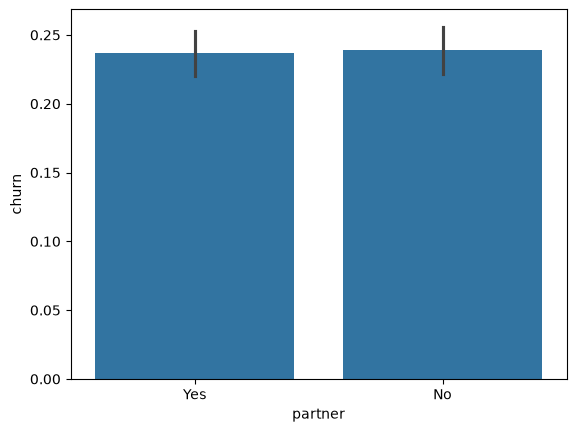

In [8]:
sns.barplot(data=df, x='partner', y=df['churn']=="Yes")

<Axes: xlabel='monthly_charges', ylabel='Density'>

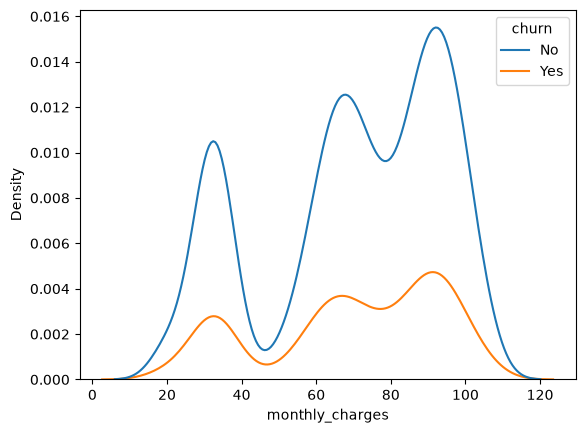

In [9]:
sns.kdeplot(data=df, x='monthly_charges',hue="churn")

In [11]:
""" EDA 06: Behavioral Signals - all engineered features 
"""
behavioral_cols = [
    "total_addon_services", "avg_charge_per_month", "is_new_customer",
    "has_any_streaming", "is_fully_automated_payer", "monthly_charges", "tenure_months",
]

In [12]:
signal_melt = df.melt(
    id_vars="churn", 
    value_vars=behavioral_cols, 
    var_name="feature", 
    value_name="value"
)

signal_melt.head()

,churn,feature,value
0,No,total_addon_services,0.0
1,No,total_addon_services,1.0
2,No,total_addon_services,0.0
3,No,total_addon_services,0.0
4,Yes,total_addon_services,2.0


<Axes: xlabel='value', ylabel='feature'>

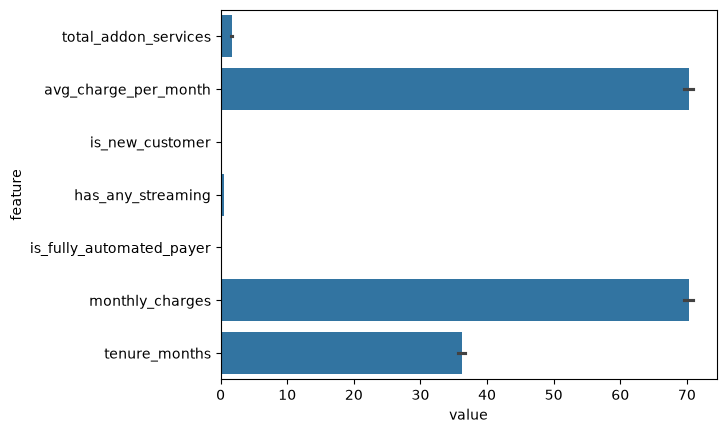

In [13]:
sns.barplot(
    data=signal_melt,
    x='value',
    y='feature',
)

In [ ]:
""" Multivariate analysis: Contract Type x Payment Method """

pivot = df.pivot_table(
    values="churn", 
    index="contract_type", 
    columns="payment_method",
    aggfunc=lambda x: (x == "Yes").mean() * 100
)
pivot

payment_method,Bank transfer,Credit card,Electronic check,Mailed check
contract_type,,,,
Month-To-Month,28.173913,24.954792,27.109005,27.606461
One Year,17.788462,22.285714,23.863636,18.141593
Two Year,21.759259,20.992366,15.763547,16.433566


<Axes: xlabel='payment_method', ylabel='contract_type'>

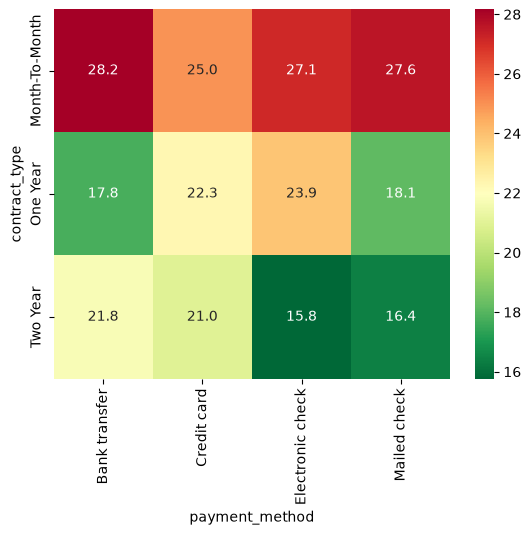

In [15]:
sns.heatmap(
    pivot, 
    annot=True, 
    fmt=".1f", 
    cmap="RdYlGn_r"
)

In [17]:
""" Multivariate analysis: Tenure Group x Contract Typ"""

pivot2 = df.pivot_table(
    values="churn", 
    index="tenure_group", 
    columns="contract_type",
    aggfunc=lambda x: (x == "Yes").mean() * 100
)
pivot2

contract_type,Month-To-Month,One Year,Two Year
tenure_group,,,
Established (25-48m),26.681128,18.910256,17.142857
Loyal (49m+),25.185972,22.619048,16.707022
Mid-term (13-24m),26.185567,19.480519,17.258883
New (0-12m),31.782946,22.641509,23.809524


<Axes: xlabel='contract_type', ylabel='tenure_group'>

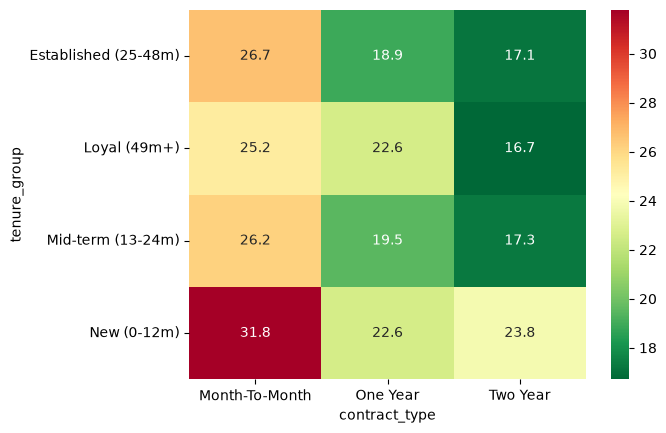

In [18]:
sns.heatmap(
    pivot2, 
    annot=True, 
    fmt=".1f", 
    cmap="RdYlGn_r"
)

'\nHypothesis: Churn risk peaks for new customers and declines with tenure \n'

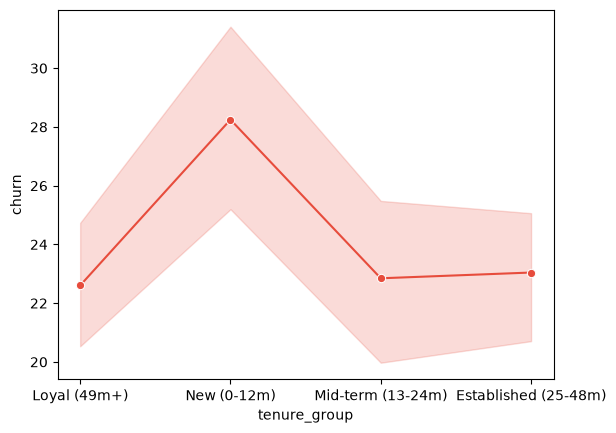

In [19]:
""" Cohort analysis: Churn rate across customer lifecycle stages """


sns.lineplot(
    data=df, 
    x="tenure_group", 
    y=(df["churn"] == "Yes").astype(int) * 100,
    estimator="mean", 
    marker="o", 
    color="#e74c3c"
)

"""
Hypothesis: Churn risk peaks for new customers and declines with tenure 
"""

C:\Users\Ishrat\AppData\Local\Temp\ipykernel_19600\4058735946.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=df, x="tenure_group", y="monthly_charges",


<Axes: xlabel='tenure_group', ylabel='monthly_charges'>

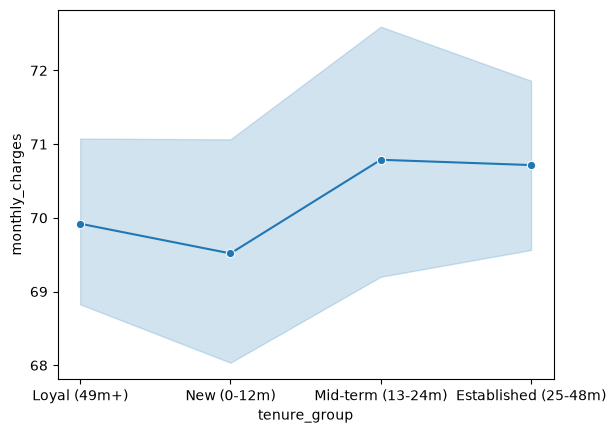

In [20]:
""" Cohort analysis: Monthly charges trajectory """
sns.lineplot(data=df, x="tenure_group", y="monthly_charges",
             estimator="mean", marker="o", palette={"Yes": "#e74c3c", "No": "#2ecc71"})

<Axes: xlabel='tenure_group', ylabel='total_addon_services'>

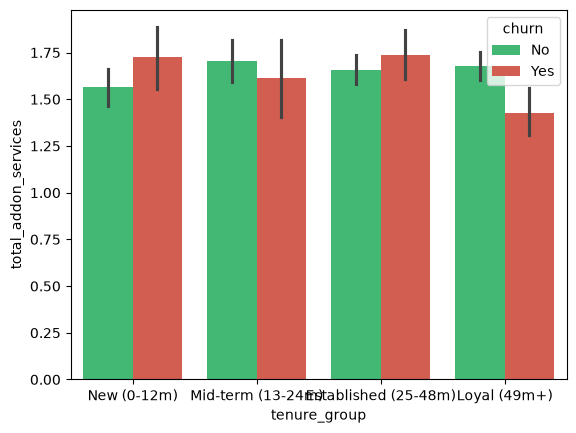

In [21]:
""" Cohort analysis: Add-on service adoption """

TENURE_ORDER = ["New (0-12m)", "Mid-term (13-24m)", "Established (25-48m)", "Loyal (49m+)"]

df["tenure_group"] = pd.Categorical(df["tenure_group"], categories=TENURE_ORDER, ordered=True)


sns.barplot(
    data=df, 
    x="tenure_group", 
    y="total_addon_services", 
    hue="churn",
    palette={"Yes": "#e74c3c", "No": "#2ecc71"}
)